In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3

In [7]:
#importing my dataset

In [9]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type = 'table'

"""

tables = pd.read_sql(sql_query, conn)

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * from {table_name}",conn)
    globals()[f"df_{table_name}"] = df
    print(f"Dreated dataframe : df_{table_name}")

conn.close()

Dreated dataframe : df_db_customer
Dreated dataframe : df_db_subscription
Dreated dataframe : df_db_support


In [11]:
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable name: {table_name}")
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("columns: ")
    print(columns['name'].tolist())

conn.close()


Table name: db_customer
columns: 
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table name: db_subscription
columns: 
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table name: db_support
columns: 
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [15]:
# df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [13]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [14]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [18]:
# renaming column

df_db_customer.rename(columns = {'name' : 'customer_name'},inplace = True)

In [19]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     str   
 1   customer_name  21 non-null     str   
 2   country        18 non-null     str   
 3   state          21 non-null     str   
 4   gender         21 non-null     str   
 5   dob            21 non-null     str   
 6   interests      4 non-null      str   
 7   pincode        0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [22]:
# droping the columns - intrest and pincode

# df_db_customer.drop(df_db_customer.columns[-2:], axis=1)

df_db_customer.drop(columns = ['interests','pincode'],inplace = True)

In [25]:
# changing dob's data type 

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [35]:
# doing standardisation of gender column

# df_db_customer['gender'].unique()

df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male' , 'Women' : 'Female'})

In [36]:
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [37]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [40]:
# df_db_customer['country'].isna()
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [43]:
# making country and state a unique pair so we can fill missing values

state_country_mapping = df_db_customer.dropna(subset = ['country']).set_index('state')['country'].to_dict()

In [45]:
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))  

In [48]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [49]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [50]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [56]:
date_col =  ['subscription_start_date' , 'renewal_date' , 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [57]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [58]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [69]:
df_db_support.drop(columns = ['comment'], inplace = True)

In [68]:
df_db_support.columns

Index(['customerid', 'complaint_date', 'escalations', 'csat_score', 'comment'], dtype='str')

In [70]:
df_db_support.columns

Index(['customerid', 'complaint_date', 'escalations', 'csat_score'], dtype='str')

In [71]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      9 non-null      str  
 1   complaint_date  9 non-null      str  
 2   escalations     9 non-null      str  
 3   csat_score      9 non-null      int64
dtypes: int64(1), str(3)
memory usage: 420.0 bytes


In [172]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [173]:
df_db_support['escalations']

2    Y
5    Y
1    Y
8    N
6    Y
4    N
3    N
Name: escalations, dtype: str

In [74]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [79]:
df_db_subscription['cancellation_date'] = np.where(df_db_subscription['cancellation_date'].notna() , 1 , 0 )

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [80]:
conn = sqlite3.connect('customer_churn.db')

df_db_subscription = pd.read_sql(
    "SELECT * FROM db_subscription",
    conn
)

conn.close()

In [81]:
np.where(df_db_subscription['cancellation_date'].notna() , 1 , 0 )

array([0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0])

In [82]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [83]:
date_col =  ['subscription_start_date' , 'renewal_date' , 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [84]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna() , 1 , 0 )

In [87]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [89]:
join_data = (df_db_subscription
                .merge(df_db_customer , on = 'customerid' , how = 'left')
                .merge(df_db_support , on = 'customerid' , how = 'left'))

In [90]:
join_data.shape

(23, 20)

In [91]:
df_db_support['customerid'].nunique()

7

In [92]:
df_db_support['customerid'].size

9

In [93]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [96]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [100]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid' , keep = 'last')

In [102]:
join_data = (df_db_subscription
                .merge(df_db_customer , on = 'customerid' , how = 'left')
                .merge(df_db_support , on = 'customerid' , how = 'left'))

In [103]:
join_data.shape

(21, 21)

In [106]:
join_data.to_csv('exported_churn_data_2.csv', index = False)

In [109]:
join_data.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [113]:
churn_rate = join_data['churn_flag'].mean()*100
print("churn rate = ", round(churn_rate,2), "%")

churn rate =  28.57 %


In [115]:
retention_rate = 100 - churn_rate
print("Retention rate = ", round(retention_rate,2), "%")

Retention rate =  71.43 %


In [117]:
join_data.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [119]:
churn_by_plan = (join_data.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [121]:
arpu = join_data['monthly_charges'].mean()
print('ARPU = ',round(arpu,2))

ARPU =  18.85


In [122]:
join_data.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [136]:
today = pd.Timestamp.today()

join_data['tenure_days'] = np.where(
        join_data['cancellation_date'].notna(),

    (join_data['cancellation_date'] - join_data['subscription_start_date']).dt.days,
    (today - join_data['subscription_start_date']).dt.days
  
)

avg_tenure = join_data['tenure_days'].mean()
print("AVG tenure in days = ", avg_tenure.round(2))

AVG tenure in days =  1540.86


In [141]:
lose_rev = join_data.loc[join_data['churn_flag'] == 1, 'monthly_charges'].sum()
print(' lose value in revenue = ', lose_rev,'K')

 lose value in revenue =  73.94 K


In [148]:
# finding escalations rate

esca_val = (join_data['escalations'] == 'Y').mean()*100
print('escalations rate = ', esca_val.round(2),'%')

escalations rate =  19.05 %


In [149]:
avg_complaints = join_data['complaint_count'].sum() / join_data['customerid'].nunique()
print('average complaints per users = ', avg_complaints.round(2))

average complaints per users =  0.43


In [170]:
# join_data['escalations'] = np.where(join_data['escalations'] == 'Y', 1, 0)

corr_data = join_data[['escalations','churn_flag']].dropna()

corr_data['escalations'].corr(join_data['churn_flag'])



np.float64(0.14142135623730956)

In [175]:
print(df_db_support.columns.tolist())
print(join_data.columns.tolist())

['customerid', 'complaint_date', 'escalations', 'csat_score', 'complaint_count']
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob', 'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'tenure_days']


In [176]:
common_cols = df_db_support.columns.intersection(join_data.columns)

print(common_cols)

Index(['customerid', 'complaint_date', 'escalations', 'csat_score',
       'complaint_count'],
      dtype='str')


In [179]:
join_data = join_data.merge(
    df_db_support[['customerid', 'escalations']],
    on='customerid',
    how='left'
)

In [182]:
print("join_data columns:")
print(join_data.columns.tolist())

print("\ndf_db_support columns:")
print(df_db_support.columns.tolist())

print("\nCommon columns:")
print(join_data.columns.intersection(df_db_support.columns).tolist())

join_data columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob', 'complaint_date', 'escalations_x', 'csat_score', 'complaint_count', 'tenure_days', 'escalations_y']

df_db_support columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'complaint_count']

Common columns:
['customerid', 'complaint_date', 'csat_score', 'complaint_count']


In [183]:
join_data['escalations'] = join_data['escalations_y']

In [184]:
print(join_data['escalations'].value_counts(dropna=False))

escalations
NaN    14
Y       4
N       3
Name: count, dtype: int64


In [189]:
# join_data['escalations'] = np.where(join_data['escalations'] == 'Y', 1, 0)

corr_data = join_data[['escalations','churn_flag']].dropna()

correlation = corr_data['escalations'].corr(join_data['churn_flag'])
print('Correlation between escalations vs churn is = ', correlation.round(2)*100, '%')

Correlation between escalations vs churn is =  77.0 %


In [190]:
join_data['churn_score'].head()

0    12
1    91
2    34
3     8
4    88
Name: churn_score, dtype: int64

In [191]:
conditions = [
    (join_data['churn_score'] < 50),
    (join_data['churn_score'] >= 50) & (join_data['churn_score'] < 70),
    (join_data['churn_score'] >= 70)
]

choices = ['low','med','high']

join_data['churn_risk'] = np.select(conditions, choices, default = 'unknown')

In [194]:
visuals = join_data.copy()

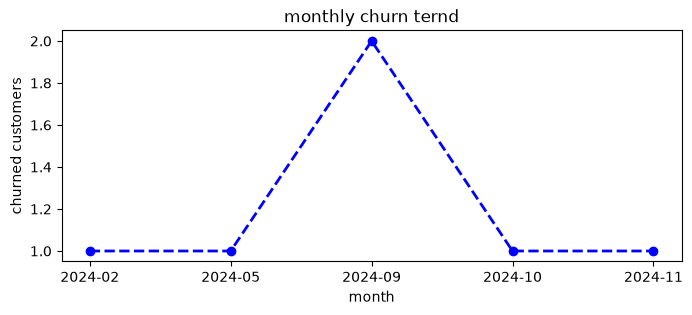

In [218]:
visuals['cancellation_month'] = visuals['cancellation_date'].dt.to_period('M')

churn_trend = visuals[visuals['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize = (8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='blue', marker='o', linestyle='dashed', linewidth=2, markersize=6)

plt.title('monthly churn ternd')
plt.xlabel('month')
plt.ylabel('churned customers')
plt.show()

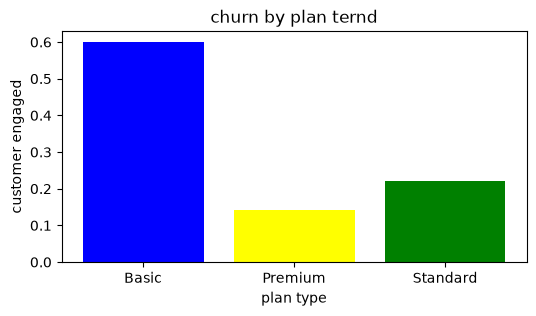

In [225]:
churn_plan = visuals.groupby('plan_type')['churn_flag'].mean()
colors = ['blue', 'yellow', 'green']
plt.figure(figsize = (6,3))
plt.bar(churn_plan.index, churn_plan.values, color = colors)
# plt.pie(
#     churn_plan.values,
#     labels=churn_plan.index,
#     colors=colors,
#     autopct='%1.1f%%'
# )

plt.title('churn by plan ternd')
plt.xlabel('plan type')
plt.ylabel('customer engaged')
plt.show()

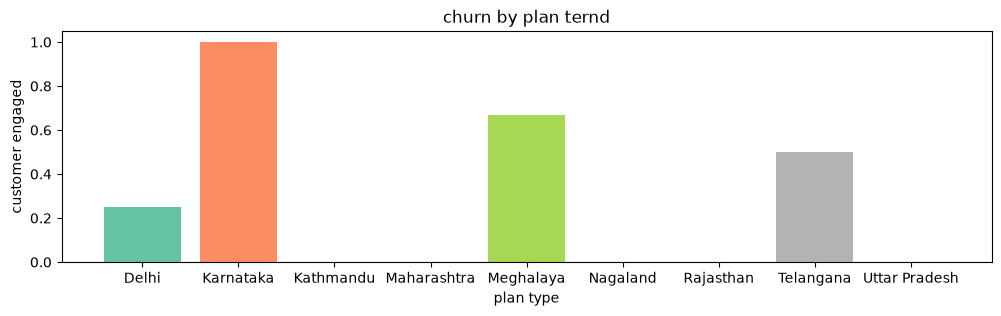

In [231]:
churn_plan = visuals.groupby('state')['churn_flag'].mean()
# colors = ['blue', 'yellow', 'green']

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize = (12,3))
plt.bar(churn_plan.index, churn_plan.values, color = colors)
# plt.pie(
#     churn_plan.values,
#     labels=churn_plan.index,
#     colors=colors,
#     autopct='%1.1f%%'
# )

plt.title('churn by plan ternd')
plt.xlabel('plan type')
plt.ylabel('customer engaged')
plt.show()

In [232]:
visuals.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations_x', 'csat_score', 'complaint_count',
       'tenure_days', 'escalations_y', 'escalations', 'churn_risk',
       'cancellation_month'],
      dtype='str')

In [233]:
visuals[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [234]:
encoded = visuals[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

categorial_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorial_cols:
    encoded[col] = encoded[col].astype('category').cat.codes

In [235]:
encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


<Axes: >

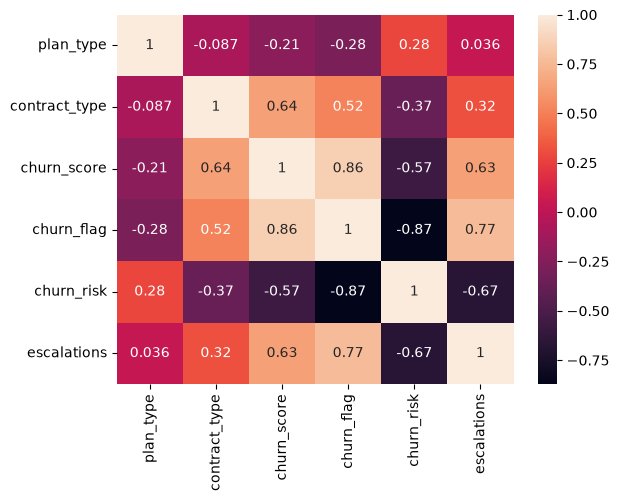

In [236]:
sns.heatmap(encoded.corr(), annot = True)

In [242]:
encoded = visuals[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

# categorial_cols = ['plan_type', 'contract_type', 'churn_risk']

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk' : ['low', 'med', 'high']
}

for col,order in order_mappings.items():
    encoded[col] = pd.Categorical(encoded[col].astype('category'),categories = order, ordered = True).codes

<Axes: >

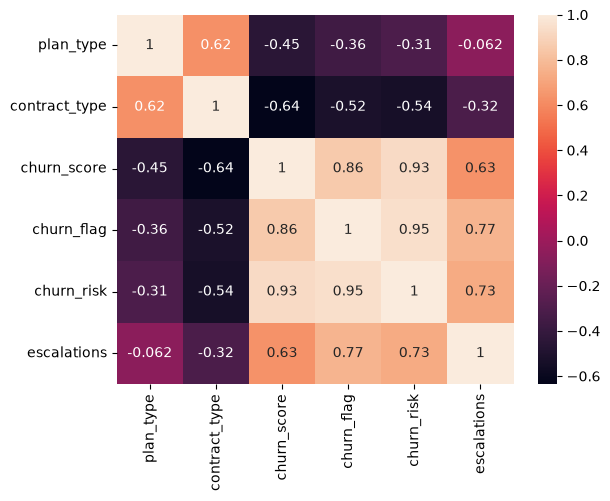

In [243]:
sns.heatmap(encoded.corr(), annot = True)

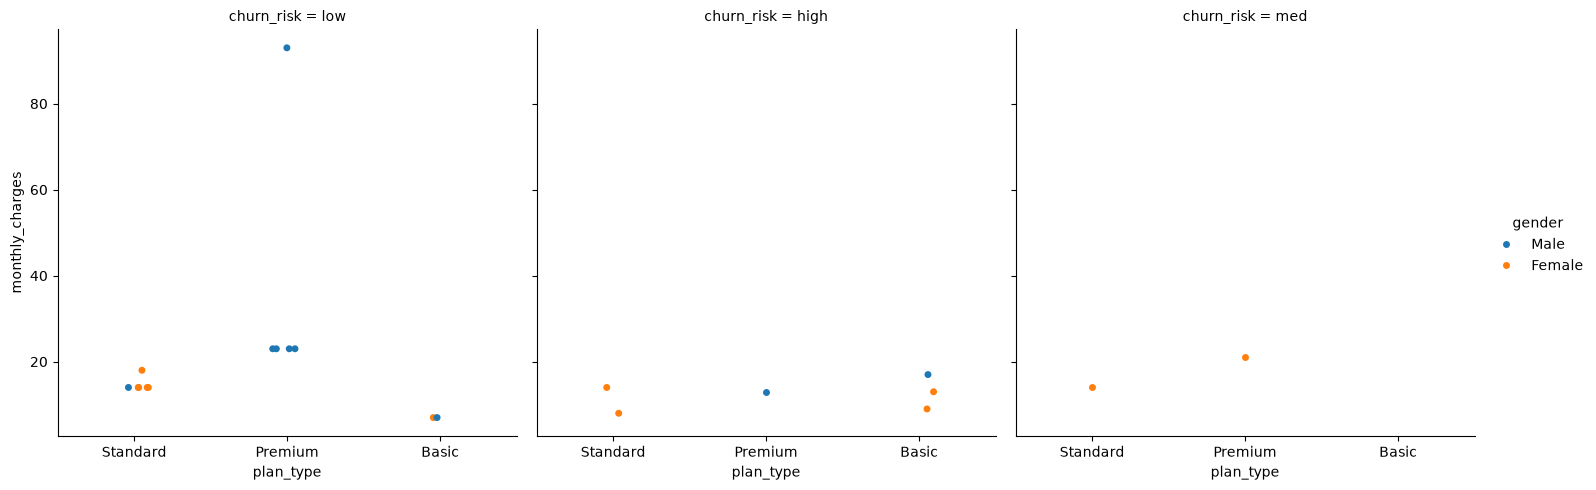

In [245]:
sns.catplot(data = visuals,
        x = 'plan_type',
        y = 'monthly_charges',
        hue = 'gender',
        col = 'churn_risk'     
    )

In [247]:
pd.pivot_table(
    visuals,
    index = 'plan_type',
    values = ['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {'monthly_charges' : 'sum',
               'customerid' : 'nunique',
               'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [248]:
conn = sqlite3.connect('test_database.sqlite')

conn.execute("CREATE TABLE user (first_name TEXT, country TEXT, budget INTEGER)")

conn.commit()

In [249]:
cursor = conn.cursor()

cursor.execute(
    """
        INSERT INTO user VALUES
        ('sohail', 'dubai', 5000),
        ('sadaf', 'india', 6000),
        ('sadika', 'india', 4000)
    """
)

conn.commit()

In [250]:
conn = sqlite3.connect('test_database.sqlite')

query = """ SELECT * FROM user"""

jd_results = pd.read_sql(query,conn)
jd_results.head()

,first_name,country,budget
0,sohail,dubai,5000
1,sadaf,india,6000
2,sadika,india,4000


In [251]:
query = """
    SELECT country,sum(budget) as total_budget
    FROM user
    GROUP BY country
"""

jd_agg = pd.read_sql(query,conn)
jd_agg

,country,total_budget
0,dubai,5000
1,india,10000


In [252]:
conn.close()